<a href="https://colab.research.google.com/github/momo25bend/streamsentinel/blob/main/streamsentinel_J4_formulaire_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# StreamSentinel · Notebook J4 : pré-remplir le formulaire OneAquaHealth

À partir d'une photo, l'IA propose une réponse pour chaque champ du formulaire
de l'app OneAquaHealth, **avec leurs codes internes**, une confiance et une
justification. Le citoyen relit, corrige et valide.

Deux sources, puis une fusion :

| Source | Champs | Pourquoi |
|---|---|---|
| **Règles** sur la segmentation et les couleurs (J1) | berges, surfaces imperméables, végétation, aspect de l'eau | mesurable, explicable |
| **Modèle vision-langage** (Qwen2.5-VL) | forme du lit, fond, seuils, tuyaux, travaux, coupes | demande de *comprendre* la scène |

Le modèle vision-langage sert aussi d'**arbitre** sur deux cas ambigus :
écume naturelle ou mousse de pollution, et présence d'un animal mort.

Règle d'or : **en cas de doute, l'IA répond `NOT_SURE`** et laisse la main au citoyen.
Les ressentis (étape 8) ne sont **jamais** remplis par l'IA.

⚙️ `Exécution > Modifier le type d'exécution > GPU T4`

## 0. Installation, GPU, Drive

In [8]:
!pip install -q transformers accelerate ultralytics

import torch, os, glob, json, re
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Appareil utilisé :", device)

from google.colab import drive
drive.mount('/content/drive')

BASE = "/content/drive/MyDrive/streamsentinel"
DOSSIERS = {k: f"{BASE}/{k}" for k in ["photos", "resultats", "modeles", "annotees"]}
for d in DOSSIERS.values():
    os.makedirs(d, exist_ok=True)

EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG")
photos = sorted(p for ext in EXTENSIONS for p in glob.glob(f"{DOSSIERS['photos']}/{ext}"))
print(len(photos), "photos")

TAILLE_MAX = 1024

def charger(chemin):
    img = ImageOps.exif_transpose(Image.open(chemin)).convert("RGB")
    img.thumbnail((TAILLE_MAX, TAILLE_MAX))
    return img

Appareil utilisé : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
50 photos


## 1. Le formulaire OneAquaHealth

Relevé dans l'app (app.enora-oah.eu). Les codes `FLAT`, `NAT`, `FAS`, `GOOD` ont
été vus dans le récapitulatif de l'étape 9 ; les autres sont provisoires.

In [9]:
FORMULAIRE = {
    # étape 4 — vue sur 100 m
    "channel_form":     {"etape": 4, "options": ["FLAT", "U_SHAPE", "V_SHAPE"], "source": "vlm"},
    "bottom_type":      {"etape": 4, "options": ["NAT", "ARTIFICIAL"], "source": "vlm"},
    "bank_type":        {"etape": 4, "options": ["NAT", "ARTIFICIAL", "LAYED_STONES"], "source": "regle+vlm"},
    "water_flow":       {"etape": 4, "options": ["FAS", "SLOW", "STAGNANT", "DRY"], "source": "vlm"},
    # étape 5
    "water_aspect":     {"etape": 5, "options": ["CLEAR", "MUDDY", "FOAM", "ALTERED_COLOR"], "source": "regle"},
    "barriers":         {"etape": 5, "options": ["YES", "NO"], "source": "vlm"},
    "draining_pipes":   {"etape": 5, "options": ["YES", "NO"], "source": "vlm"},
    "sewage_discharge": {"etape": 5, "options": ["YES", "NO"], "source": "vlm"},
    "construction":     {"etape": 5, "options": ["YES", "NO"], "source": "vlm"},
    # étape 6 — berges sur 5 à 10 m
    "impervious_left":       {"etape": 6, "options": ["YES", "NO"], "source": "regle"},
    "impervious_right":      {"etape": 6, "options": ["YES", "NO"], "source": "regle"},
    "vegetation_left":       {"etape": 6, "options": ["YES", "NO"], "source": "regle"},
    "vegetation_right":      {"etape": 6, "options": ["YES", "NO"], "source": "regle"},
    "vegetation_type_left":  {"etape": 6, "options": ["HERBS", "SHRUBS", "TREES"], "source": "regle"},
    "vegetation_type_right": {"etape": 6, "options": ["HERBS", "SHRUBS", "TREES"], "source": "regle"},
    "vegetation_cuts":       {"etape": 6, "options": ["YES", "NO"], "source": "vlm"},
}

# laissés au citoyen, et pourquoi
LAISSES_AU_CITOYEN = {
    "research_site": "choix du site officiel",
    "water_height": "mesure physique, impossible sur photo",
    "water_withdrawal": "pompage rarement visible",
    "habitats": "sous-options non relevées dans l'app",
    "natural_debris": "sous-options non relevées dans l'app",
    "invasive_species": "liste d'espèces non relevée dans l'app",
    "feelings": "ressenti personnel : l'IA ne le remplit jamais",
}

SEUIL_CONFIANCE = 0.6   # en dessous : NOT_SURE
print(len(FORMULAIRE), "champs pré-remplis par l'IA,", len(LAISSES_AU_CITOYEN), "laissés au citoyen")

16 champs pré-remplis par l'IA, 7 laissés au citoyen


## 2. Segmentation fine (reprise du J1)

Par rapport au J1, on distingue maintenant les **trois étages de végétation**
demandés par le formulaire : herbes, arbustes, arbres. SegFormer (ADE20K) sait
séparer `grass`, `plant` et `tree`.

In [10]:
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation

SEG_ID = "nvidia/segformer-b2-finetuned-ade-512-512"
seg_processor = SegformerImageProcessor.from_pretrained(SEG_ID)
seg_model = SegformerForSemanticSegmentation.from_pretrained(SEG_ID).to(device).eval()

GROUPES = {
    1: ("eau",         ["water", "sea", "river", "lake", "waterfall"]),
    2: ("arbres",      ["tree", "palm"]),
    3: ("herbes",      ["grass", "field", "flower"]),
    4: ("arbustes",    ["plant"]),
    5: ("impermeable", ["building", "wall", "house", "road", "sidewalk", "bridge", "skyscraper",
                        "fence", "railing", "column", "stairs", "pier", "car", "bench", "path"]),
    6: ("sol_naturel", ["earth", "rock", "sand", "mountain", "hill", "dirt track"]),
    7: ("ciel",        ["sky"]),
}
EAU, ARBRES, HERBES, ARBUSTES, IMPER, SOL, CIEL = 1, 2, 3, 4, 5, 6, 7
VEGETATION = [ARBRES, HERBES, ARBUSTES]

table = np.zeros(len(seg_model.config.id2label), dtype=np.uint8)
for idx, nom in seg_model.config.id2label.items():
    court = nom.split(";")[0].strip().lower()
    for g, (_, classes) in GROUPES.items():
        if court in classes:
            table[int(idx)] = g

def nettoyer_eau(masque, part_min=0.01):
    eau = (masque == EAU).astype(np.uint8)
    eau = cv2.morphologyEx(eau, cv2.MORPH_CLOSE, np.ones((7, 7), np.uint8))
    n, etiquettes, stats, _ = cv2.connectedComponentsWithStats(eau)
    garder = np.zeros_like(eau)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= part_min * masque.size:
            garder[etiquettes == i] = 1
    propre = masque.copy()
    propre[(masque == EAU) & (garder == 0)] = 0
    propre[(garder == 1) & (masque != EAU)] = EAU
    return propre

@torch.no_grad()
def segmenter(img_pil):
    entrees = seg_processor(images=img_pil, return_tensors="pt").to(device)
    seg = seg_processor.post_process_semantic_segmentation(
        seg_model(**entrees), target_sizes=[img_pil.size[::-1]])[0]
    return nettoyer_eau(table[seg.cpu().numpy().astype(np.int64)])

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

## 3. Analyse de l'eau (seuils finaux du J1)

In [11]:
def analyser_eau(img_pil, masque):
    eau = (masque == EAU)
    if eau.sum() < 0.05 * masque.size:
        return None
    rgb = np.array(img_pil)
    hsv = cv2.cvtColor(rgb, cv2.COLOR_RGB2HSV)
    h, s, v = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    gris = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    n = eau.sum()

    texture_locale = cv2.blur(np.abs(cv2.Laplacian(gris, cv2.CV_64F)), (15, 15))
    blanc = (eau & (s < 60) & (v > 175) & (texture_locale < 25)).astype(np.uint8)
    blanc = cv2.morphologyEx(blanc, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    part_mousse = blanc.sum() / n

    part_vert = (eau & (h >= 30) & (h <= 90) & (s > 50) & (v > 40)).sum() / n
    texture_eau = float(np.abs(cv2.Laplacian(gris, cv2.CV_64F))[eau].mean())

    part_brun = (eau & (h >= 8) & (h <= 30) & (s > 50)).sum() / n
    score_turb = float(np.clip(0.7 * part_brun + 0.3 * (1 - min(texture_eau / 20, 1)), 0, 1))

    return {"mousse": float(part_mousse), "vert": float(part_vert),
            "eau_lisse": texture_eau < 25, "turbidite": score_turb}

## 4. Les règles : de la mesure au champ du formulaire

**Rive gauche / rive droite.** L'app les définit **en regardant vers l'aval**.
Sur une photo prise vers l'aval, la moitié gauche de l'image est donc la rive
gauche ; sur une photo prise vers l'amont, c'est l'inverse.

Chaque règle renvoie une valeur, une confiance et une raison lisible.

In [12]:
def reponse(valeur, confiance, raison, source="regle"):
    return {"valeur": valeur, "confiance": round(float(confiance), 2), "raison": raison, "source": source}

def pas_sur(raison, source="regle"):
    return reponse("NOT_SURE", 0.0, raison, source)

def marges(masque, epaisseur=0.06):
    # anneau de pixels autour de l'eau, découpé en moitié gauche et droite de l'image
    eau = (masque == EAU).astype(np.uint8)
    k = max(5, int(masque.shape[1] * epaisseur))
    anneau = (cv2.dilate(eau, np.ones((k, k), np.uint8)) - eau).astype(bool)
    anneau &= (masque != CIEL)
    milieu = masque.shape[1] // 2
    gauche, droite = anneau.copy(), anneau.copy()
    gauche[:, milieu:] = False
    droite[:, :milieu] = False
    return {"image_gauche": masque[gauche], "image_droite": masque[droite], "tout": masque[anneau]}

def regles_berges(masque, orientation="aval"):
    m = marges(masque)
    # conversion image -> rive, selon le sens de la photo
    if orientation == "aval":
        rives = {"left": m["image_gauche"], "right": m["image_droite"]}
    else:
        rives = {"left": m["image_droite"], "right": m["image_gauche"]}

    champs = {}
    for cote, pix in rives.items():
        if pix.size < 500:
            for nom in ["impervious", "vegetation", "vegetation_type"]:
                champs[f"{nom}_{cote}"] = pas_sur("rive trop peu visible")
            continue

        part_imper = float(np.isin(pix, [IMPER]).mean())
        part_veg = float(np.isin(pix, VEGETATION).mean())

        # surfaces imperméables : question « plus d'un tiers de la marge ? »
        if part_imper > 0.40:
            champs[f"impervious_{cote}"] = reponse("YES", min(1, 0.6 + part_imper / 2), f"{part_imper:.0%} de surfaces artificielles")
        elif part_imper < 0.20:
            champs[f"impervious_{cote}"] = reponse("NO", min(1, 0.6 + (0.2 - part_imper) * 2), f"{part_imper:.0%} de surfaces artificielles")
        else:
            champs[f"impervious_{cote}"] = pas_sur(f"{part_imper:.0%}, proche du seuil d'un tiers")

        # présence de végétation
        if part_veg > 0.25:
            champs[f"vegetation_{cote}"] = reponse("YES", min(1, 0.6 + part_veg / 2), f"{part_veg:.0%} de végétation")
        elif part_veg < 0.08:
            champs[f"vegetation_{cote}"] = reponse("NO", 0.7, f"{part_veg:.0%} de végétation")
        else:
            champs[f"vegetation_{cote}"] = pas_sur(f"{part_veg:.0%} de végétation, cas limite")

        # type dominant : doit dépasser 50 % de la végétation
        veg = pix[np.isin(pix, VEGETATION)]
        if veg.size > 300:
            parts = {code: float((veg == g).mean()) for code, g in
                     [("TREES", ARBRES), ("HERBS", HERBES), ("SHRUBS", ARBUSTES)]}
            dominant, part = max(parts.items(), key=lambda x: x[1])
            if part > 0.5:
                champs[f"vegetation_type_{cote}"] = reponse(dominant, 0.5 + part / 2, f"{part:.0%} de la végétation")
            else:
                champs[f"vegetation_type_{cote}"] = pas_sur("aucun étage ne dépasse 50 %")
        else:
            champs[f"vegetation_type_{cote}"] = pas_sur("pas assez de végétation visible")

    # type de berge (les deux rives confondues)
    tout = m["tout"]
    if tout.size > 500:
        part_imper = float((tout == IMPER).mean())
        if part_imper > 0.6:
            champs["bank_type"] = reponse("ARTIFICIAL", 0.5 + part_imper / 2, f"{part_imper:.0%} de berge artificielle")
        elif part_imper < 0.3:
            champs["bank_type"] = reponse("NAT", 0.5 + (1 - part_imper) / 2, f"{part_imper:.0%} de berge artificielle")
        else:
            champs["bank_type"] = pas_sur(f"berge mixte ({part_imper:.0%} artificielle)")
    return champs

def regle_eau(analyse):
    # choix unique dans l'app : priorité mousse > couleur anormale > boue > claire
    if analyse is None:
        return pas_sur("eau pas assez visible")
    if analyse["mousse"] > 0.14:
        return reponse("FOAM", min(1, 0.6 + analyse["mousse"]), f"mousse sur {analyse['mousse']:.0%} de l'eau")
    if analyse["vert"] > 0.18 and analyse["eau_lisse"]:
        return reponse("ALTERED_COLOR", min(1, 0.55 + analyse["vert"]), f"eau verte sur {analyse['vert']:.0%} de la surface")
    if analyse["turbidite"] > 0.35:
        return reponse("MUDDY", min(1 , 0.5 + analyse["turbidite"] / 2), f"turbidité {analyse['turbidite']:.2f}")
    if analyse["turbidite"] < 0.30:
        return reponse("CLEAR", 0.85 - analyse["turbidite"], f"turbidité {analyse['turbidite']:.2f}")
    return pas_sur(f"turbidité intermédiaire ({analyse['turbidite']:.2f})")

## 5. Le modèle vision-langage

**Qwen2.5-VL-3B** regarde la photo et répond aux questions qui demandent de
comprendre la scène. On lui impose les options exactes du formulaire, et on lui
demande de répondre `NOT_SURE` dès qu'un élément n'est pas clairement visible.

⏱️ Premier chargement : 3 à 5 minutes (environ 7 Go).

⚠️ Si les réponses sont illisibles (suites de `!!!!` ou texte vide), passez
`DTYPE` à `torch.float32` : certaines cartes T4 gèrent mal le float16 avec ce modèle.

In [13]:
from transformers import AutoProcessor, AutoModelForImageTextToText

VLM_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
DTYPE = torch.float16

vlm_processor = AutoProcessor.from_pretrained(VLM_ID, min_pixels=256 * 28 * 28, max_pixels=640 * 28 * 28)
vlm = AutoModelForImageTextToText.from_pretrained(VLM_ID, torch_dtype=DTYPE, device_map="auto").eval()
print("Modèle vision-langage chargé")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Modèle vision-langage chargé


In [14]:
QUESTIONS_VLM = {
    "channel_form": "Cross-section shape of the stream channel. FLAT = wide and flat bottom, "
                    "U_SHAPE = rounded with steep banks, V_SHAPE = narrow and deep like a V.",
    "bottom_type": "Stream bed material. NAT = natural (gravel, stones, sand, mud), "
                   "ARTIFICIAL = concrete or paved bottom. Answer NOT_SURE if the bottom is not visible.",
    "bank_type": "Banks. NAT = natural soil and plants, ARTIFICIAL = concrete walls, "
                 "LAYED_STONES = placed stones or riprap without concrete.",
    "water_flow": "Water flow. FAS = fast, SLOW = slow, STAGNANT = standing water, DRY = no water. "
                  "Only answer if clearly visible from ripples or still surface.",
    "barriers": "Is there a weir, dam, sluice or other barrier across the stream? YES or NO.",
    "draining_pipes": "Is there a pipe or drain outlet flowing into the stream? YES or NO.",
    "sewage_discharge": "Is there a visible discharge of dirty water, sewage or foam coming from a pipe? YES or NO.",
    "construction": "Are there construction works, machinery or building sites near the stream? YES or NO.",
    "vegetation_cuts": "Are there signs of recent vegetation cutting or mowing on the banks? YES or NO.",
}

def construire_prompt():
    lignes = [
        "You are helping a citizen fill in an urban stream observation form.",
        "Look at the photo and answer each field with ONE of the allowed options, or NOT_SURE.",
        "Answer NOT_SURE whenever the element is not clearly visible. Never guess.",
        "",
    ]
    for champ, question in QUESTIONS_VLM.items():
        options = FORMULAIRE[champ]["options"] + ["NOT_SURE"]
        lignes.append(f'- "{champ}": {question} Allowed: {", ".join(options)}.')
    lignes += [
        "- \"overall\": overall stream quality. GOOD = natural channel, riparian vegetation, clean water; "
        "MODERATE = some alterations; POOR = highly artificial, little vegetation or polluted. Allowed: GOOD, MODERATE, POOR.",
        "",
        "Reply with JSON only, no other text, in this exact format:",
        '{"field_name": {"value": "OPTION", "confidence": 0.0-1.0, "reason": "short reason"}}',
    ]
    return "\n".join(lignes)

PROMPT_VLM = construire_prompt()

def extraire_json(texte):
    trouve = re.search(r"\{.*\}", texte, re.DOTALL)
    if not trouve:
        return {}
    try:
        return json.loads(trouve.group(0))
    except json.JSONDecodeError:
        return {}

@torch.no_grad()
def interroger_vlm(img_pil, prompt=None, max_new_tokens=700):
    prompt = prompt or PROMPT_VLM
    messages = [{"role": "user", "content": [{"type": "image", "image": img_pil},
                                             {"type": "text", "text": prompt}]}]
    try:
        entrees = vlm_processor.apply_chat_template(
            messages, add_generation_prompt=True, tokenize=True,
            return_dict=True, return_tensors="pt").to(vlm.device)
    except Exception:
        # versions antérieures de transformers : image passée à part
        gabarit = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": prompt}]}]
        texte = vlm_processor.apply_chat_template(gabarit, add_generation_prompt=True, tokenize=False)
        entrees = vlm_processor(text=[texte], images=[img_pil], return_tensors="pt").to(vlm.device)

    sortie = vlm.generate(**entrees, max_new_tokens=max_new_tokens, do_sample=False)
    brut = vlm_processor.batch_decode(sortie[:, entrees["input_ids"].shape[1]:], skip_special_tokens=True)[0]
    return extraire_json(brut), brut

# test
test_json, test_brut = interroger_vlm(charger(photos[0]))
print(test_brut[:800])

{
  "channel_form": {"value": "FLAT", "confidence": 0.8, "reason": "The stream appears to be wide and flat"},
  "bottom_type": {"value": "NOT_SURE", "confidence": 0.6, "reason": "The bottom is not visible"},
  "bank_type": {"value": "ARTIFICIAL", "confidence": 0.9, "reason": "Concrete walls along the banks"},
  "water_flow": {"value": "SLOW", "confidence": 0.8, "reason": "The water is calm"},
  "barriers": {"value": "NO", "confidence": 0.95, "reason": "No barriers are visible"},
  "draining_pipes": {"value": "NOT_SURE", "confidence": 0.7, "reason": "Drains are not visible"},
  "sewage_discharge": {"value": "NOT_SURE", "confidence": 0.6, "reason": "No visible discharge"},
  "construction": {"value": "NOT_SURE", "confidence": 0.5, "reason": "Construction works are not visible"},
  "vegetatio


## 5 bis. Arbitrage des cas ambigus

Deux questions ciblées, posées seulement quand elles sont utiles :

1. **Écume ou mousse ?** Les règles de couleur du J1 confondent l'écume blanche
   d'une cascade avec une mousse de pollution. Si elles détectent de la mousse,
   on demande au modèle de trancher.
2. **Poisson ou animal mort ?** Le modèle public testé au J3 a été écarté.
   Ce signalement ne va pas dans le formulaire, mais dans `signalements` :
   il servira au score de risque du J5, **toujours avec validation humaine
   avant toute alerte**.

In [24]:
PROMPT_ECUME = (
    "Look at the white patches on the water surface. Classify them as:\n"
    "- POLLUTION_FOAM: persistent foam floating on calm or slow water, often yellowish or grey, "
    "typical of detergents or sewage;\n"
    "- NATURAL_WHITEWATER: white water created by rapids, a waterfall, a weir or turbulence;\n"
    "- NOT_SURE if you cannot tell.\n"
    'Reply with JSON only: {\"value\": \"OPTION\", \"confidence\": 0.0-1.0, \"reason\": \"short reason\"}'
)

PROMPT_ANIMAL = (
    "Look carefully at the water. Can you identify the body of a dead animal, "
    "with visible body parts such as a head, an eye, fins, a tail, scales, "
    "feathers or fur?\n"
    "Answer YES only if such body parts are visible. "
    "Answer NO for any man-made object or if no animal body is visible.\n"
    'Reply with JSON only: {\"value\": \"YES|NO|NOT_SURE\", \"confidence\": 0.0-1.0, ' + \
    '\"reason\": \"short reason\"}'
)

def lire_reponse(brut, options, source):
    if not isinstance(brut, dict) or "value" not in brut:
        return pas_sur("réponse illisible", source)
    valeur = str(brut.get("value", "")).upper().strip()
    raison = str(brut.get("reason", ""))[:120]
    if valeur == "NOT_SURE":
        return pas_sur(raison or "le modèle n'a pas pu trancher", source)
    if valeur not in options:
        return pas_sur("réponse hors options", source)
    try:
        conf = min(float(brut.get("confidence", 0.5)), 0.8)
    except (TypeError, ValueError):
        conf = 0.5
    return reponse(valeur, conf, raison, source)

def arbitrer_ecume(img_pil):
    brut, _ = interroger_vlm(img_pil, PROMPT_ECUME, max_new_tokens=120)
    return lire_reponse(brut, ["POLLUTION_FOAM", "NATURAL_WHITEWATER"], "arbitrage")

def detecter_animal_mort(img_pil):
    brut, _ = interroger_vlm(img_pil, PROMPT_ANIMAL, max_new_tokens=120)
    r = lire_reponse(brut, ["YES", "NO"], "vlm")
    r["a_valider"] = r["valeur"] == "YES"   # jamais d'alerte sans validation humaine
    return r

print("prompts et lecture des réponses à jour")

prompts et lecture des réponses à jour


## 6. Fusion des deux sources

- Les deux sources sont d'accord → la confiance augmente.
- Elles se contredisent → on garde la plus sûre, **seulement si** elle dépasse le seuil.
- Sinon → `NOT_SURE`.

On ne fait pas une confiance aveugle au modèle vision-langage : sa confiance
déclarée est peu fiable, on la plafonne à 0,8.

In [16]:
def normaliser_vlm(brut_vlm, champ):
    r = brut_vlm.get(champ)
    if not isinstance(r, dict):
        return None
    valeur = str(r.get("value", "NOT_SURE")).upper().strip()
    options = FORMULAIRE[champ]["options"] if champ in FORMULAIRE else ["GOOD", "MODERATE", "POOR"]
    if valeur not in options:
        return pas_sur("réponse du modèle hors options", "vlm")
    try:
        conf = min(float(r.get("confidence", 0.5)), 0.8)
    except (TypeError, ValueError):
        conf = 0.5
    return reponse(valeur, conf, str(r.get("reason", ""))[:120], "vlm")

def fusionner(regle, vlm_r):
    candidats = [c for c in (regle, vlm_r) if c and c["valeur"] != "NOT_SURE"]
    if not candidats:
        return regle or vlm_r or pas_sur("aucune source")
    if len(candidats) == 2 and candidats[0]["valeur"] == candidats[1]["valeur"]:
        conf = min(1.0, max(c["confiance"] for c in candidats) + 0.15)
        return reponse(candidats[0]["valeur"], conf,
                       f"{candidats[0]['raison']} ; confirmé par le modèle", "regle+vlm")
    meilleur = max(candidats, key=lambda c: c["confiance"])
    if len(candidats) == 2:
        meilleur = dict(meilleur, raison=meilleur["raison"] + " (sources en désaccord)",
                        confiance=round(meilleur["confiance"] - 0.1, 2))
    return meilleur

def appliquer_seuil(r):
    if r["valeur"] != "NOT_SURE" and r["confiance"] < SEUIL_CONFIANCE:
        return dict(r, valeur="NOT_SURE", raison=f"confiance trop faible ({r['confiance']}) — {r['raison']}")
    return r

## 7. Évaluation globale Good / Moderate / Poor

On reprend **les critères de OneAquaHealth** eux-mêmes (écran d'instructions de
l'app) : végétation de berge, lit naturel, qualité de l'eau, biodiversité, degré
d'artificialisation. Chaque réponse ajoute ou retire des points, et la raison
est affichée au citoyen.

Les déchets détectés par le modèle du J3 sont aussi pris en compte, s'il est
présent sur le Drive.

In [17]:
from ultralytics import YOLO

CHEMIN_DECHETS = f"{DOSSIERS['modeles']}/dechets/weights/best.pt"
modele_dechets = YOLO(CHEMIN_DECHETS) if os.path.exists(CHEMIN_DECHETS) else None
print("Détecteur de déchets :", "chargé" if modele_dechets else "absent (ignoré)")

def detecter_dechets(img_pil, seuil=0.4):
    if modele_dechets is None:
        return None
    boites = modele_dechets(img_pil, conf=seuil, verbose=False)[0].boxes
    return [{"classe": modele_dechets.names[int(b.cls)], "confiance": round(float(b.conf), 2),
             "boite": [int(v) for v in b.xyxy[0].tolist()]} for b in boites]

POINTS = {
    ("bank_type", "NAT"): (2, "berges naturelles"),
    ("bank_type", "LAYED_STONES"): (0, "berges en pierres posées"),
    ("bank_type", "ARTIFICIAL"): (-2, "berges artificielles"),
    ("bottom_type", "ARTIFICIAL"): (-1, "fond artificiel"),
    ("vegetation_left", "YES"): (1, "végétation rive gauche"),
    ("vegetation_right", "YES"): (1, "végétation rive droite"),
    ("vegetation_left", "NO"): (-1, "pas de végétation rive gauche"),
    ("vegetation_right", "NO"): (-1, "pas de végétation rive droite"),
    ("impervious_left", "YES"): (-1, "rive gauche imperméable"),
    ("impervious_right", "YES"): (-1, "rive droite imperméable"),
    ("water_aspect", "CLEAR"): (2, "eau claire"),
    ("water_aspect", "MUDDY"): (-1, "eau boueuse"),
    ("water_aspect", "FOAM"): (-2, "mousse en surface"),
    ("water_aspect", "ALTERED_COLOR"): (-2, "couleur de l'eau anormale"),
    ("barriers", "YES"): (-1, "obstacle dans le lit"),
    ("sewage_discharge", "YES"): (-3, "rejet d'eaux usées"),
    ("construction", "YES"): (-1, "travaux à proximité"),
}

def evaluer(formulaire, nb_dechets, avis_vlm, animal_mort=None):
    score, raisons = 0, []
    if animal_mort and animal_mort["valeur"] == "YES":
        score -= 3
        raisons.append("-3 animal mort signalé (à confirmer par un humain)")
    for champ, r in formulaire.items():
        if (champ, r["valeur"]) in POINTS:
            pts, texte = POINTS[(champ, r["valeur"])]
            score += pts
            raisons.append(f"{'+' if pts >= 0 else ''}{pts} {texte}")
    if nb_dechets:
        pts = -2 if nb_dechets >= 3 else -1
        score += pts
        raisons.append(f"{pts} {nb_dechets} déchet(s) détecté(s)")

    note_regles = "GOOD" if score >= 3 else "POOR" if score <= -2 else "MODERATE"
    note = note_regles
    accord = None
    if avis_vlm and avis_vlm["valeur"] in ("GOOD", "MODERATE", "POOR"):
        accord = avis_vlm["valeur"] == note_regles
        if not accord:
            raisons.append(f"le modèle vision-langage propose {avis_vlm['valeur']} : à vérifier par le citoyen")
    return {"valeur": note, "score": score, "raisons": raisons,
            "accord_modele": accord, "confiance": 0.8 if accord else 0.55}

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Détecteur de déchets : chargé


## 8. Image annotée pour le citoyen

Quand le citoyen relit la fiche, il doit voir **ce que l'IA a regardé** :
les zones eau / végétation / surfaces artificielles, la séparation entre rive
gauche et rive droite (selon le sens de la photo) et les déchets détectés.
C'est plus utile qu'un schéma générique, et c'est l'IA explicable attendue par
le Track 3.

In [18]:
COULEURS_MASQUE = {EAU: (40, 120, 255), ARBRES: (20, 140, 40), HERBES: (120, 200, 60),
                   ARBUSTES: (70, 170, 50), IMPER: (220, 60, 60), SOL: (150, 110, 60)}

def annoter(img_pil, masque, orientation, dechets):
    image = np.array(img_pil).copy()
    calque = image.copy()
    for g, couleur in COULEURS_MASQUE.items():
        calque[masque == g] = couleur
    image = cv2.addWeighted(image, 0.6, calque, 0.4, 0)

    h, w = image.shape[:2]
    cv2.line(image, (w // 2, 0), (w // 2, h), (255, 255, 255), 2)
    gauche, droite = ("RIVE GAUCHE", "RIVE DROITE") if orientation == "aval" else ("RIVE DROITE", "RIVE GAUCHE")
    taille = max(0.5, w / 1400)
    for texte, x in [(gauche, 12), (droite, w // 2 + 12)]:
        cv2.putText(image, texte, (x, 34), cv2.FONT_HERSHEY_SIMPLEX, taille, (0, 0, 0), 5)
        cv2.putText(image, texte, (x, 34), cv2.FONT_HERSHEY_SIMPLEX, taille, (255, 255, 255), 2)

    for d in dechets or []:
        x1, y1, x2, y2 = d["boite"]
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 200, 0), 2)
        cv2.putText(image, d["classe"], (x1, max(y1 - 6, 14)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 200, 0), 2)
    return Image.fromarray(image)

## 9. Pipeline J4 complet


=== berge_betonnee_00.jpg — pré-rempli à 56% ===
  channel_form           FLAT           0.80  [vlm] The stream appears to be wide and flat
  bottom_type            NOT_SURE       0.00  [vlm] réponse du modèle hors options
  bank_type              ARTIFICIAL     1.00  [regle+vlm] 84% de berge artificielle ; confirmé par le modèle
  water_flow             SLOW           0.80  [vlm] The water is calm
  water_aspect           CLEAR          0.70  [regle] turbidité 0.15
  barriers               NO             0.80  [vlm] No barriers are visible
  draining_pipes         NOT_SURE       0.00  [vlm] réponse du modèle hors options
  sewage_discharge       NOT_SURE       0.00  [vlm] réponse du modèle hors options
  construction           NOT_SURE       0.00  [vlm] réponse du modèle hors options
  impervious_left        YES            0.98  [regle] 77% de surfaces artificielles
  impervious_right       YES            1.00  [regle] 92% de surfaces artificielles
  vegetation_left        NOT_SURE  

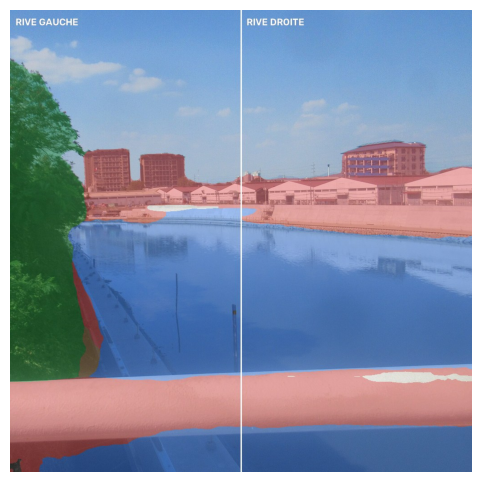


=== berge_betonnee_01.jpg — pré-rempli à 62% ===
  channel_form           FLAT           0.80  [vlm] The stream appears to be wide and flat
  bottom_type            NAT            0.80  [vlm] The bottom seems to be made of natural materials
  bank_type              ARTIFICIAL     1.00  [regle+vlm] 100% de berge artificielle ; confirmé par le modèle
  water_flow             SLOW           0.80  [vlm] The water is calm and there are no visible ripples
  water_aspect           CLEAR          0.63  [regle] turbidité 0.22
  barriers               NO             0.80  [vlm] There are no barriers visible
  draining_pipes         NOT_SURE       0.00  [vlm] réponse du modèle hors options
  sewage_discharge       NOT_SURE       0.00  [vlm] réponse du modèle hors options
  construction           NOT_SURE       0.00  [vlm] réponse du modèle hors options
  impervious_left        YES            1.00  [regle] 100% de surfaces artificielles
  impervious_right       YES            1.00  [regle] 100% d

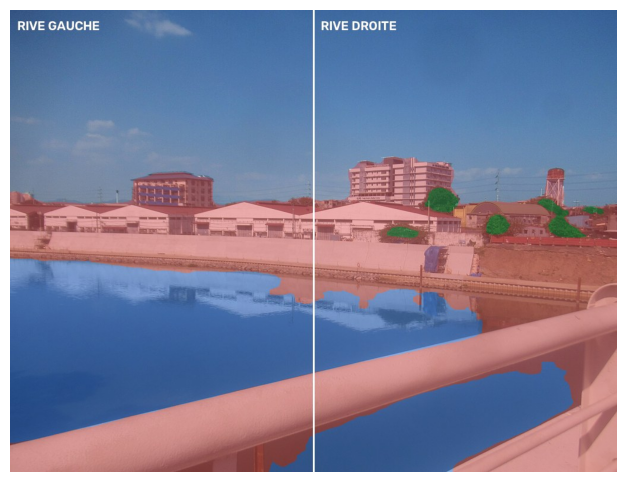

berge_betonnee_02.jpg → Cours d'eau pas assez visible : la photo doit être reprise (voir J2).


In [19]:
def prefill(chemin, orientation="aval"):
    img = charger(chemin)
    masque = segmenter(img)
    if (masque == EAU).mean() < 0.05:
        return {"photo": os.path.basename(chemin), "valide": False,
                "message": "Cours d'eau pas assez visible : la photo doit être reprise (voir J2)."}

    regles = regles_berges(masque, orientation)
    analyse = analyser_eau(img, masque)
    regles["water_aspect"] = regle_eau(analyse)

    brut_vlm, _ = interroger_vlm(img)

    formulaire = {}
    for champ in FORMULAIRE:
        r_regle = regles.get(champ)
        r_vlm = normaliser_vlm(brut_vlm, champ) if champ in QUESTIONS_VLM else None
        formulaire[champ] = appliquer_seuil(fusionner(r_regle, r_vlm))

    # arbitrage écume / mousse
    arbitrages = {}
    if formulaire["water_aspect"]["valeur"] == "FOAM":
        arb = arbitrer_ecume(img)
        arbitrages["ecume_ou_mousse"] = arb
        if arb["valeur"] == "NATURAL_WHITEWATER" and arb["confiance"] >= 0.5:
            nouveau = regle_eau(dict(analyse, mousse=0.0))
            formulaire["water_aspect"] = appliquer_seuil(dict(
                nouveau, source="regle+arbitrage",
                raison=nouveau["raison"] + " ; blanc = écume naturelle selon le modèle"))
        elif arb["valeur"] == "NOT_SURE":
            formulaire["water_aspect"] = pas_sur("mousse ou écume naturelle : à confirmer", "arbitrage")

    # signalements hors formulaire, pour le J5
    animal = detecter_animal_mort(img)
    dechets = detecter_dechets(img)
    nb_dechets = len(dechets) if dechets is not None else None

    evaluation = evaluer(formulaire, nb_dechets, normaliser_vlm(brut_vlm, "overall"), animal)

    image_annotee = annoter(img, masque, orientation, dechets)
    chemin_annote = f"{DOSSIERS['annotees']}/{os.path.splitext(os.path.basename(chemin))[0]}.jpg"
    image_annotee.save(chemin_annote, quality=88)

    remplis = sum(r["valeur"] != "NOT_SURE" for r in formulaire.values())
    return {
        "photo": os.path.basename(chemin),
        "valide": True,
        "orientation": orientation,
        "formulaire": formulaire,
        "overall_assessment": evaluation,
        "arbitrages": arbitrages,
        "signalements": {"animal_mort": animal, "dechets": dechets},
        "image_annotee": chemin_annote,
        "laisses_au_citoyen": LAISSES_AU_CITOYEN,
        "taux_prefill": round(remplis / len(FORMULAIRE), 2),
    }

import matplotlib.pyplot as plt

def afficher_fiche(r):
    if not r["valide"]:
        print(r["photo"], "→", r["message"]); return
    print(f"\n=== {r['photo']} — pré-rempli à {r['taux_prefill']:.0%} ===")
    for champ, rep in r["formulaire"].items():
        print(f"  {champ:22s} {rep['valeur']:14s} {rep['confiance']:.2f}  [{rep['source']}] {rep['raison']}")
    e = r["overall_assessment"]
    print(f"  {'OVERALL':22s} {e['valeur']:14s} score {e['score']}  → " + " ; ".join(e["raisons"]))
    for nom, a in r["arbitrages"].items():
        print(f"  arbitrage {nom} : {a['valeur']} ({a['confiance']}) — {a['raison']}")
    a = r["signalements"]["animal_mort"]
    print(f"  animal mort : {a['valeur']} ({a['confiance']})" + (" ⚠️ à valider" if a.get("a_valider") else ""))
    plt.figure(figsize=(9, 6)); plt.imshow(Image.open(r["image_annotee"])); plt.axis("off"); plt.show()

exemples = [p for p in photos if os.path.basename(p).startswith(("berge", "mousse", "eau_"))][:3]
for p in exemples:
    afficher_fiche(prefill(p))

## 10. Passage sur le jeu de test

In [25]:
from tqdm.auto import tqdm

candidates = [p for p in photos if not os.path.basename(p).startswith(("sans_eau", "rate_"))]
candidates = [p for p in candidates if not os.path.basename(p).startswith("dechets")] + \
             [p for p in candidates if os.path.basename(p).startswith("dechets")][:5]

resultats_j4, ignorees = [], []
for p in tqdm(candidates):
    try:
        resultats_j4.append(prefill(p))
    except Exception as e:
        ignorees.append((os.path.basename(p), type(e).__name__, str(e)[:80]))

with open(f"{DOSSIERS['resultats']}/resultats_j4.json", "w", encoding="utf-8") as f:
    json.dump(resultats_j4, f, ensure_ascii=False, indent=2)

valides = [r for r in resultats_j4 if r["valide"]]
print(f"{len(valides)} fiches produites, {len(ignorees)} erreurs")
if ignorees: print(ignorees)
print("Taux de pré-remplissage moyen :", round(np.mean([r["taux_prefill"] for r in valides]) * 100), "%")
print("Évaluations :", pd.Series([r["overall_assessment"]["valeur"] for r in valides]).value_counts().to_dict())
print("Arbitrages écume/mousse :", [(r["photo"], r["arbitrages"]["ecume_ou_mousse"]["valeur"])
                                   for r in valides if "ecume_ou_mousse" in r["arbitrages"]])
print("Animaux morts signalés :", [r["photo"] for r in valides if r["signalements"]["animal_mort"]["valeur"] == "YES"])

  0%|          | 0/19 [00:00<?, ?it/s]

15 fiches produites, 0 erreurs
Taux de pré-remplissage moyen : 65 %
Évaluations : {'MODERATE': 6, 'POOR': 5, 'GOOD': 4}
Arbitrages écume/mousse : [('berge_naturelle_01.jpg', 'NATURAL_WHITEWATER'), ('mousse_00.jpg', 'NATURAL_WHITEWATER'), ('mousse_01.jpg', 'NATURAL_WHITEWATER'), ('mousse_02.jpg', 'NATURAL_WHITEWATER')]
Animaux morts signalés : ['dechets_001.jpg']


## 11. Évaluation par l'humain

On ne peut pas juger ces réponses automatiquement : il faut regarder les photos.
Cette cellule crée un tableau sur le Drive, avec une ligne par réponse de l'IA.

1. Ouvrez `verification_j4.csv` dans Google Sheets.
2. Pour chaque ligne, mettez **1** dans `correct` si la réponse est juste, **0** sinon.
   Laissez vide les `NOT_SURE`.
3. Enregistrez au format CSV sous le même nom, puis lancez la cellule suivante.

In [21]:
lignes = []
for r in valides:
    for champ, rep in r["formulaire"].items():
        lignes.append({"photo": r["photo"], "champ": champ, "valeur_ia": rep["valeur"],
                       "confiance": rep["confiance"], "source": rep["source"],
                       "raison": rep["raison"], "correct": ""})
    for nom, a in r["arbitrages"].items():
        lignes.append({"photo": r["photo"], "champ": f"arbitrage_{nom}", "valeur_ia": a["valeur"],
                       "confiance": a["confiance"], "source": a["source"], "raison": a["raison"], "correct": ""})
    a = r["signalements"]["animal_mort"]
    lignes.append({"photo": r["photo"], "champ": "animal_mort", "valeur_ia": a["valeur"],
                   "confiance": a["confiance"], "source": a["source"], "raison": a["raison"], "correct": ""})
    e = r["overall_assessment"]
    lignes.append({"photo": r["photo"], "champ": "overall_assessment", "valeur_ia": e["valeur"],
                   "confiance": e["confiance"], "source": "score", "raison": " ; ".join(e["raisons"]),
                   "correct": ""})

verif = pd.DataFrame(lignes)
verif.to_csv(f"{BASE}/verification_j4.csv", index=False, encoding="utf-8")
print(len(verif), "réponses à vérifier →", f"{BASE}/verification_j4.csv")

274 réponses à vérifier → /content/drive/MyDrive/streamsentinel/verification_j4.csv


In [22]:
chemin = f"{BASE}/verification_j4.csv"
v = pd.read_csv(chemin)
repondu = v[v["valeur_ia"] != "NOT_SURE"]
note = repondu.dropna(subset=["correct"])

if len(note) == 0:
    print("Colonne 'correct' encore vide : remplissez-la dans Google Sheets.")
else:
    print(f"Précision des réponses données : {note['correct'].mean():.1%} ({len(note)} réponses notées)")
    print(f"Taux d'abstention (NOT_SURE) : {(v['valeur_ia'] == 'NOT_SURE').mean():.1%}")
    print("\nPrécision par champ :")
    print((note.groupby("champ")["correct"].agg(["mean", "count"])
              .rename(columns={"mean": "precision", "count": "n"})
              .sort_values("precision")).round(2))
    print("\nPrécision par source :")
    print(note.groupby("source")["correct"].agg(["mean", "count"]).round(2))

Colonne 'correct' encore vide : remplissez-la dans Google Sheets.


In [23]:
for nom in ["eau_boueuse_00.jpg", "eau_boueuse_01.jpg", "berge_betonnee_00.jpg"]:
    img = charger(f"{DOSSIERS['photos']}/{nom}")
    m = segmenter(img)
    print(nom, "part eau :", round(float((m == EAU).mean()), 3), analyser_eau(img, m))

eau_boueuse_00.jpg part eau : 0.344 {'mousse': 0.11198513663915999, 'vert': 0.0008735328417309253, 'eau_lisse': False, 'turbidite': 0.40811010947982673}
eau_boueuse_01.jpg part eau : 0.302 {'mousse': 0.10098345196129062, 'vert': 0.0013640343983654041, 'eau_lisse': True, 'turbidite': 0.5377624222556525}
berge_betonnee_00.jpg part eau : 0.348 {'mousse': 0.11605687214180223, 'vert': 7.946098054849997e-05, 'eau_lisse': True, 'turbidite': 0.14539238654204995}
